# Model training

The training phase begins with preprocessing the dataset. Audio files and their corresponding annotations are loaded, and features are extracted to create the model input (X) and target labels (Y). This process converts raw recordings into a structured format suitable for machine learning, where each example represents a segment of audio and its associated presence or absence of the target species.

In [ ]:
# Run this once at the start of your Colab session
#!pip install "numpy<1.25" numba librosa resampy soundfile
#!pip install resampy

In [1]:
try:
    # mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/GithubProject/bioacoustic-detection
except:
    pass


Mounted at /content/drive
/content/drive/MyDrive/GithubProject/bioacoustic-detection


In [2]:
import sys
import os
from data_process.preprocessing import *
from training.train_helper import *

# Define the path to your project folder
project_path = '/content/drive/MyDrive/GithubProject/bioacoustic-detection'
# Add the 'src' directory to sys.path
sys.path.append(os.path.join(project_path, 'src'))
# Move the working directory to your project folder
os.chdir(project_path)

## 1. Data processing

In [6]:
species_folder = '/content/drive/MyDrive/GithubProject/bioacoustic-detection' # Should contain /Audio and /Annotations
lowpass_cutoff = 3500 # Cutt off for low pass filter
downsample_rate = 8000 # Frequency to downsample to
nyquist_rate = 4000 # Nyquist rate (half of sampling rate)
segment_duration = 4 # how long should a segment be
positive_class = ['gibbon'] # which labels should be bundled together for the positive  class
background_class = ['no-gibbon'] # which labels should be bundled together for the negative  class
file_type = 'svl'
audio_extension = '.wav'
n_fft = 1024 # Hann window length
hop_length = 256 # Sepctrogram hop size
n_mels = 128 # Spectrogram number of mells
f_min = 400 # Spectrogram, minimum frequency for call
f_max = 4000 # Spectrogram, maximum frequency for call
save_results_folder = 'Saved_Data'

In [7]:
pre_pro = preprocessing(species_folder,
                        lowpass_cutoff,
                        downsample_rate,
                        nyquist_rate,
                        segment_duration,
                        positive_class,
                        background_class,
                        n_fft,
                        hop_length,
                        n_mels,
                        f_min,
                        f_max,
                        file_type,
                        audio_extension
                    )

In [ ]:
#X, Y = pre_pro.create_dataset(True)

Processing: HGSM3AB_0+1_20160303_060100
Processing: HGSM3AB_0+1_20160305_055900
Processing: HGSM3AB_0+1_20160317_055000
Processing: HGSM3AB_0+1_20160331_053800
Processing: HGSM3AC_0+1_20150716_051400
Processing: HGSM3AC_0+1_20150717_051400
Processing: HGSM3AC_0+1_20150807_052200
Processing: HGSM3C_0+1_20150805_052100
Processing: HGSM3C_0+1_20150807_052200
Processing: HGSM3C_0+1_20150812_052300


In [ ]:
## check distrubution of classes
pre_pro.check_distribution(Y)

{'gibbon': np.int64(1929), 'no-gibbon': np.int64(1746)}

In [ ]:
# Save data to pickle file
pre_pro.save_spec_data_to_pickle(X, Y)

In [9]:
# check shape of the imnputs
X.shape, Y.shape

((3675, 128, 126), (3675,))

In [11]:
# create function to plot random examples of spectrograms from dataset
import random
import matplotlib.pyplot as plt
def plot_random_spec_from_dataset(X: Array, Y: Array, num_examples: int = 5) -> None:
    indices = random.sample(range(X.shape[0]), num_examples)
    plt.figure(figsize=(5, 3 * num_examples))
    for i, idx in enumerate(indices):
        plt.subplot(num_examples, 1, i + 1)
        plt.imshow(X[idx], aspect='auto', origin='lower', cmap='magma')
        plt.title(f"Label: {Y[idx]}")
        plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()

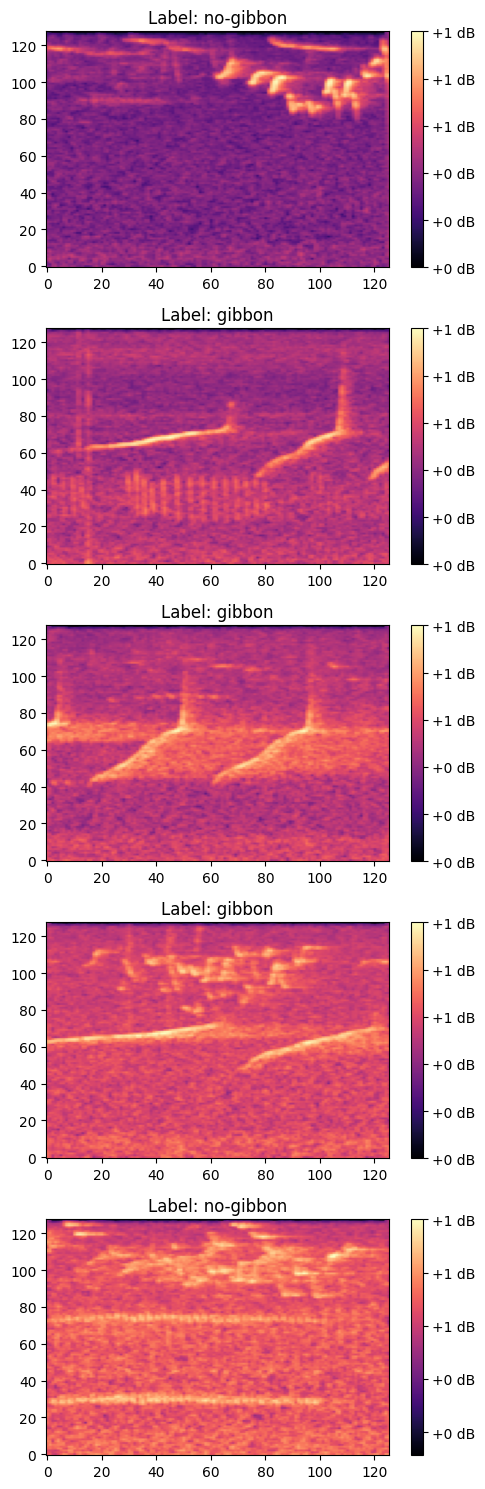

In [12]:
plot_random_spec_from_dataset(X_S, Y_S, num_examples=5)

## 2. Training

Once the dataset is prepared, it is used to train the model, allowing it to learn patterns in the features that indicate species calls.

In [ ]:
# Load the data saved as pickle
X_S, Y_S = pre_pro.load_spec_data_from_pickle()

In [13]:
# Config
species_key= 'gibbon_params'
model_name = 'baseline_cnn'
number_of_run = 1
mod_train = train_helper(species_folder)

Original split shapes
Training__:  (2940, 128, 126, 1)
Validation:  (735, 128, 126, 1)
Presence: 1393, Absence: 1547
Augmenting 'no-gibbon' by 154
Shapes (after augmentation):
X_calls_train (3094, 128, 126, 1)
X_calls_test (735, 128, 126, 1)
y_train (3094, 2)
y_test (735, 2)
Training distribution: {np.int64(0): np.int64(1547), np.int64(1): np.int64(1547)}


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 124, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,515,970 (24.86 MB)

 Trainable params: 6,515,970 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10

Epoch 1: val_loss improved from inf to 0.29881, saving model to Saved_weights/baseline_cnn_20260128_12_best.keras
25/25 - 15s - 605ms/step - accuracy: 0.6658 - loss: 0.6100 - val_accuracy: 0.9741 - val_loss: 0.2988 - learning_rate: 1.0000e-03
Epoch 2/10

Epoch 2: val_loss improved from 0.29881 to 0.08518, saving model to Saved_weights/baseline_cnn_20260128_12_best.keras
25/25 - 2s - 77ms/step - accuracy: 0.9224 - loss: 0.2146 - val_accuracy: 0.9796 - val_loss: 0.0852 - learning_rate: 1.0000e-03
Epoch 3/10

Epoch 3: val_loss improved from 0.08518 to 0.06044, saving model to Saved_weights/baseline_cnn_20260128_12_best.keras
25/25 - 2s - 80ms/step - accuracy: 0.9732 - loss: 0.0892 - val_accuracy: 0.9810 - val_loss: 0.0604 - learning_rate: 1.0000e-03
Epoch 4/10

Epoch 4: val_loss improved from 0.06044 to 0.05203, saving model to Saved_weights/baseline_cnn_20260128_12_best.keras
25/25 - 2s - 76ms/step - accuracy: 0.9790 - loss: 0.0654 - val_accuracy: 0.9810 - val_loss: 0.0520 - 

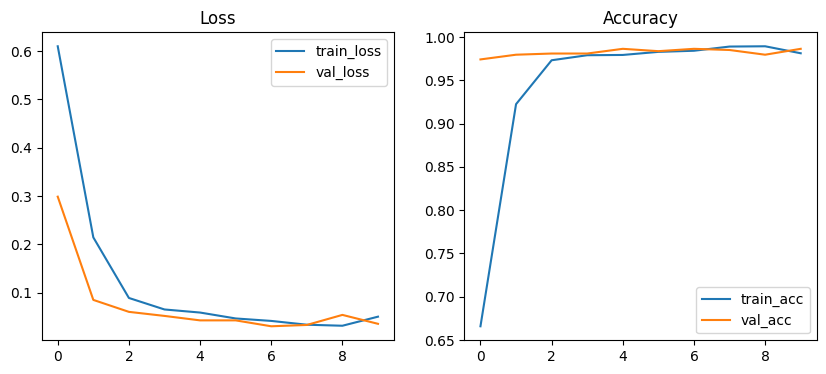

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step


NameError: name 'confusion_matrix' is not defined

In [14]:
# run training
mod_train.train(X_S, Y_S, species_key, model_name,1)